In [21]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor
import shap
from scipy.stats import zscore
from scipy.spatial import cKDTree
import os
import fiona
from geopy.distance import geodesic

In [22]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")

In [23]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"🛑 Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [24]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [25]:
doubs_data = doubs_data.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(doubs_data)
doubs_data.dropna(axis=1, thresh=threshold, inplace=True)

doubs_data.dropna(inplace=True)

In [26]:
doubs_data.shape

(2679, 62)

In [27]:
caserne['compagnie'] = caserne['compagnie'].replace('Maîche', 'Maiche')

caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y
compagnies = compagnies.to_crs(epsg=4326)

caserne = caserne.merge(compagnies[['id', 'nom']], left_on='compagnie', right_on='nom', how='left')

caserne = caserne.rename(columns={'id': 'id_compagnie'})

if 'nom' in caserne.columns:
    caserne = caserne.drop(columns=['nom'])

none_count = caserne['id_compagnie'].isna().sum()
print(f"Nombre de casernes sans id_compagnie : {none_count}")

print(caserne[['compagnie', 'id_compagnie']].head())

if 'nom_y' in caserne.columns:
    caserne = caserne.drop(columns=['nom_y'])

Nombre de casernes sans id_compagnie : 0
         compagnie  id_compagnie
0         Besançon           1.0
1  Baume-les-Dames           2.0
2      Montbéliard           6.0
3       Pontarlier           4.0
4      Montbéliard           6.0


In [28]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
compagnies = gpd.GeoDataFrame(compagnies, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
compagnies = compagnies.to_crs(epsg=4326)

doubs_data['id_compagnie'] = None

for idx, hexagone in doubs_data.iterrows():
    intersecting_companies = compagnies[compagnies.intersects(hexagone['geometry'])]

    if len(intersecting_companies) == 1:
        doubs_data.at[idx, 'id_compagnie'] = intersecting_companies.iloc[0]['id']
    elif len(intersecting_companies) > 1:
        max_area = 0
        best_company_id = None
        for _, company in intersecting_companies.iterrows():
            intersection = hexagone['geometry'].intersection(company['geometry'])
            area = intersection.area
            if area > max_area:
                max_area = area
                best_company_id = company['id']

        doubs_data.at[idx, 'id_compagnie'] = best_company_id

print(doubs_data[['hex_id', 'id_compagnie']].head())

            hex_id id_compagnie
0  871f820aaffffff          4.0
1  871f82d61ffffff         12.0
2  871f82d61ffffff         12.0
3  871f82d4dffffff          1.0
4  871f82700ffffff          5.0


In [29]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
caserne = caserne.to_crs(epsg=4326)

doubs_data['id_caserne'] = None
doubs_data['distance'] = None

for idx, hexagone in doubs_data.iterrows():
    casernes_same_company = caserne[caserne['id_compagnie'] == hexagone['id_compagnie']]

    if casernes_same_company.empty:
        continue

    distances = casernes_same_company.geometry.distance(hexagone['geometry'])

    nearest_caserne_idx = distances.idxmin()
    nearest_caserne = casernes_same_company.loc[nearest_caserne_idx]

    doubs_data.at[idx, 'id_caserne'] = nearest_caserne['id_pg']
    doubs_data.at[idx, 'distance'] = distances.min()

print(doubs_data[['hex_id', 'id_compagnie', 'id_caserne', 'distance']].head())

Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



            hex_id id_compagnie id_caserne  distance
0  871f820aaffffff          4.0     840709       0.0
1  871f82d61ffffff         12.0     840704  0.005327
2  871f82d61ffffff         12.0     840704  0.005327
3  871f82d4dffffff          1.0     840698  0.039716
4  871f82700ffffff          5.0     840701  0.010387


In [30]:
doubs_data.columns

Index(['hex_id', 'raison_sortie', 'date_debut', 'date_fin', 'label', 'year',
       'date', 'departement', 'duree_minutes', 'geometry', 'duree', 'centroid',
       'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday', 'scale0',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'sinister', 'id_compagnie', 'id_caserne',
       'distance'],
      dtype='object')

In [31]:
cols_to_drop = [
    'raison_sortie', 'label', 'departement', 'duree',
    'centroid', 'index', 'longitude', 'latitude', 'sinister',
       'id_compagnie', 'id_caserne', 'date_debut', 'date_fin', 'year', 'date', 'geometry', 'scale0', 'hour', 'month', 'weekday'
]

doubs_data = doubs_data.drop(columns=[col for col in cols_to_drop if col in doubs_data.columns])

In [32]:
doubs_data.columns

Index(['hex_id', 'duree_minutes', 'centroid_lon', 'centroid_lat', 'NDVI',
       'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway', 'primary',
       'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'distance'],
      dtype='object')

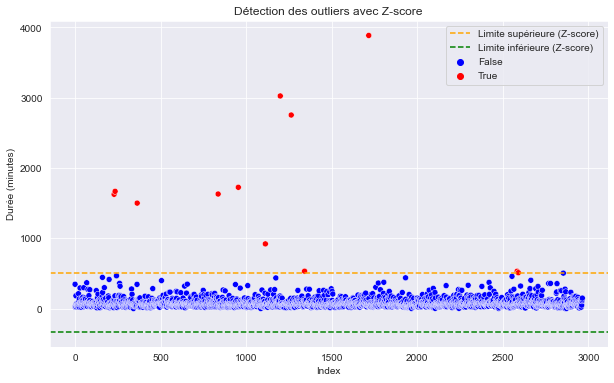

In [33]:
Z_THRESHOLD = 3

doubs_data["z_score"] = zscore(doubs_data["duree_minutes"])

doubs_data["is_outlier"] = abs(doubs_data["z_score"]) > Z_THRESHOLD

plt.figure(figsize=(10, 6))
sns.scatterplot(x=doubs_data.index, y=doubs_data["duree_minutes"], hue=doubs_data["is_outlier"], palette={True: "red", False: "blue"})

plt.axhline(y=doubs_data["duree_minutes"].mean() + Z_THRESHOLD * doubs_data["duree_minutes"].std(), color='orange', linestyle='--', label="Limite supérieure (Z-score)")
plt.axhline(y=doubs_data["duree_minutes"].mean() - Z_THRESHOLD * doubs_data["duree_minutes"].std(), color='green', linestyle='--', label="Limite inférieure (Z-score)")

plt.xlabel("Index")
plt.ylabel("Durée (minutes)")
plt.title("Détection des outliers avec Z-score")
plt.legend()
plt.show()

In [34]:
doubs_data = doubs_data[doubs_data["is_outlier"] == False]
print(doubs_data.shape)

(2667, 50)


In [35]:
cols_to_drop = [
    'is_outlier', 'z_score'
]

doubs_data = doubs_data.drop(columns=[col for col in cols_to_drop if col in doubs_data.columns])

In [36]:
colonnes_numeriques = [
    'duree_minutes', 'centroid_lon', 'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI',
    'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population',
    'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
    'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC',
    'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
    'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub',
    'flooded', 'built', 'bare', 'snow', 'distance'
]

df_agg = doubs_data.groupby('hex_id')[colonnes_numeriques].mean()

df_agg.reset_index(inplace=True)

print(df_agg.head())

            hex_id  duree_minutes  centroid_lon  centroid_lat      NDVI  \
0  871f80492ffffff     117.325000      6.350198     47.477082  0.720443   
1  871f80493ffffff      79.483333      6.381746     47.480996  0.739361   
2  871f80498ffffff     160.133333      6.444873     47.488800  0.785204   
3  871f8049affffff      65.383333      6.431903     47.468880  0.778036   
4  871f8049cffffff      89.400000      6.426270     47.504821  0.751272   

       NDMI      NDBI      NDSI      NDWI  PasDeRoute  ...  Sapin, épicéa  \
0  0.145452 -0.145452 -0.593620 -0.672639   96.116627  ...       0.000000   
1  0.162564 -0.162564 -0.599609 -0.688388   95.966830  ...       0.728735   
2  0.193932 -0.193932 -0.627573 -0.728378   97.701871  ...       5.035791   
3  0.189057 -0.189057 -0.623016 -0.721208   96.609318  ...       0.941856   
4  0.175163 -0.175163 -0.599002 -0.693667   96.231629  ...       0.000000   

      water       tree      grass     crops     shrub   flooded     built  \
0  0.0125

In [37]:
df_agg.columns

Index(['hex_id', 'duree_minutes', 'centroid_lon', 'centroid_lat', 'NDVI',
       'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway', 'primary',
       'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow'],
      dtype='object')

In [38]:
y = df_agg['duree_minutes']

X = df_agg.drop(columns=['hex_id', 'duree_minutes'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(objective="reg:squarederror", random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"📊 Performance du modèle XGBoost :")
print(f"✅ MAE  : {mae:.4f}")
print(f"✅ MSE  : {mse:.4f}")
print(f"✅ RMSE : {rmse:.4f}")
print(f"✅ R²   : {r2:.4f}")

📊 Performance du modèle XGBoost :
✅ MAE  : 39.1031
✅ MSE  : 3178.0571
✅ RMSE : 56.3743
✅ R²   : -0.5978


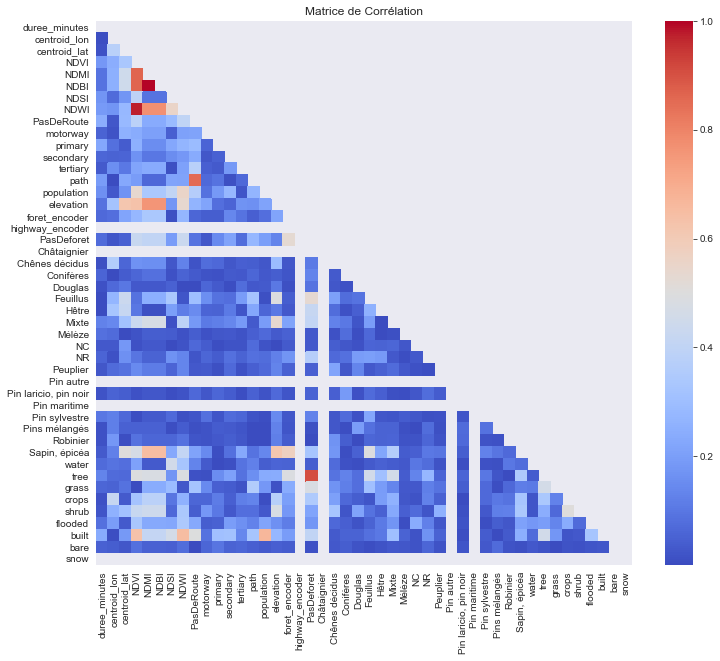

🔹 3 features à retirer : {'NDBI', 'NDWI', 'tree'}
✅ Nombre de features après filtrage : 44


In [39]:
corr_matrix = df_agg.corr().abs()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", annot=False, fmt=".2f")
plt.title("Matrice de Corrélation")
plt.show()

correlated_features = set()
threshold = 0.9

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            colname = corr_matrix.columns[i]
            correlated_features.add(colname)

print(f"🔹 {len(correlated_features)} features à retirer : {correlated_features}")

df_agg_filtered = df_agg.drop(columns=correlated_features)

print(f"✅ Nombre de features après filtrage : {df_agg_filtered.shape[1]}")

In [40]:
y = df_agg_filtered['duree_minutes']

X = df_agg_filtered.drop(columns=['hex_id', 'duree_minutes'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(objective="reg:squarederror", random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"📊 Performance du modèle XGBoost :")
print(f"✅ MAE  : {mae:.4f}")
print(f"✅ MSE  : {mse:.4f}")
print(f"✅ RMSE : {rmse:.4f}")
print(f"✅ R²   : {r2:.4f}")

📊 Performance du modèle XGBoost :
✅ MAE  : 37.7989
✅ MSE  : 3180.7748
✅ RMSE : 56.3984
✅ R²   : -0.5992
